# Setup

In [8]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
import sys
sys.path.append("../")

from utils.seed_all import seed_all

DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

In [10]:
def plot_img_loss(img_loss, min=None, max=None, targets=[], name='Mean Image Loss Map'):
    plt.figure(figsize=(10, 8))  # Adjust size as needed
    plt.imshow(img_loss, cmap='gray_r', aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i, color='red', linewidth=1.5, alpha=0.2)  # top edge
            # plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title(name)
    plt.tight_layout()
    plt.show()
    plt.close()

# Prediction

In [11]:
path = '../runs/tcn_pred_TOWIDS_20250912_185140/train_labels_predictions.pt'
cache = torch.load(path, weights_only=False)
y_true, y_out = cache['y_true'], cache['y_scores']
y_pred, y_scores = y_out
y_pred = np.array(y_pred)
y_scores = np.array(y_scores)

In [12]:
y_true['scores'] = y_scores.mean(axis=(1, 2))

In [13]:
y_true.head()

,label,start_idx,desc_windows,scores
0,PTP Sync,1049025,"[Normal, Normal, PTP Sync, Normal, PTP Sync, N...",0.115039
1,Switch MAC Flooding,667651,"[Switch MAC Flooding, Normal, Switch MAC Flood...",0.082601
2,Normal,45202,"[Normal, Normal, Normal, Normal, Normal, Norma...",0.009545
3,Switch MAC Flooding,606311,"[Normal, Normal, Normal, Switch MAC Flooding, ...",0.074347
4,PTP Sync,994885,"[Normal, Normal, PTP Sync, Normal, Normal, PTP...",0.149881


In [14]:
fp = y_true[(y_true['scores'] > 0.013931273482739925) & (y_true['label'] == 'Normal')].index
tn = y_true[(y_true['scores'] <= 0.013931273482739925) & (y_true['label'] != 'Normal')].index

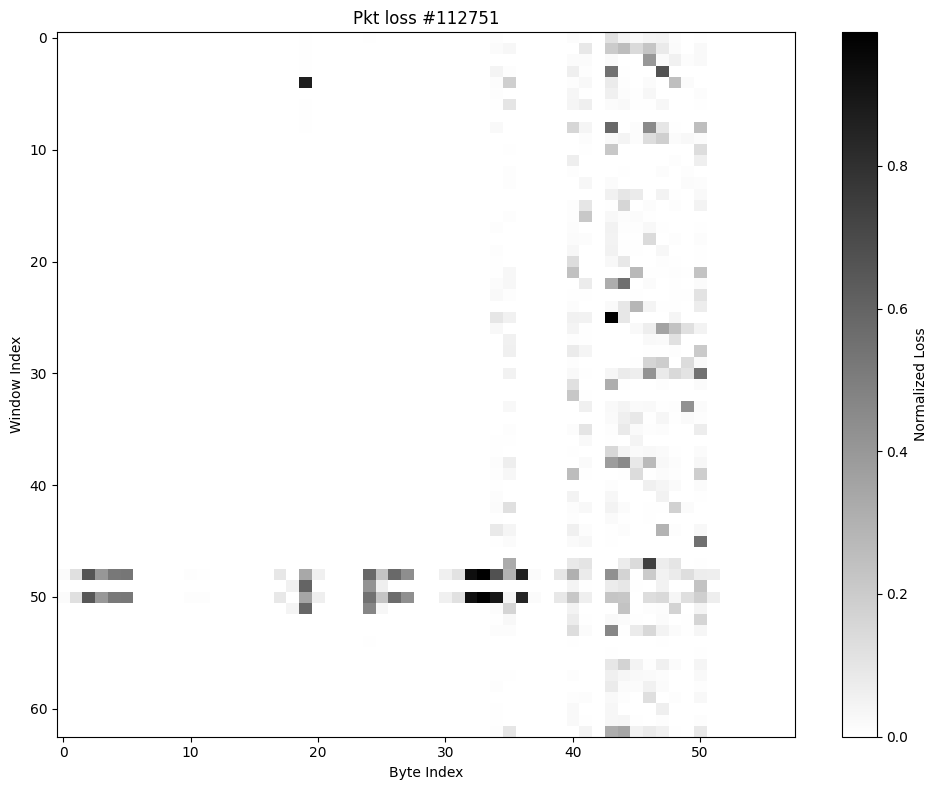

In [ ]:
# This is a noise: 112818 and 112820 of DHCP protocol
idx = fp[0]
plot_img_loss(y_scores[idx], targets=y_true['desc_windows'].iloc[idx][1:], name=f'Pkt loss #{y_true['start_idx'].iloc[idx]}')

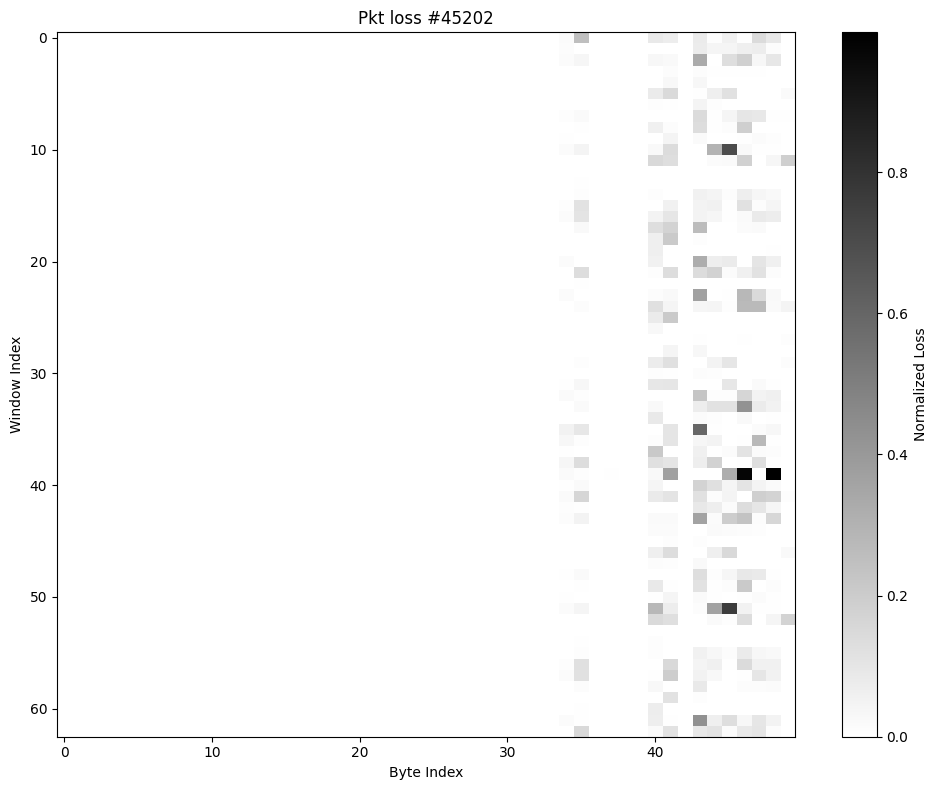

In [20]:
# This is a noise: 112818 and 112820 of DHCP protocol
idx = 2
plot_img_loss(y_scores[idx], targets=y_true['desc_windows'].iloc[idx][1:], name=f'Pkt loss #{y_true['start_idx'].iloc[idx]}')

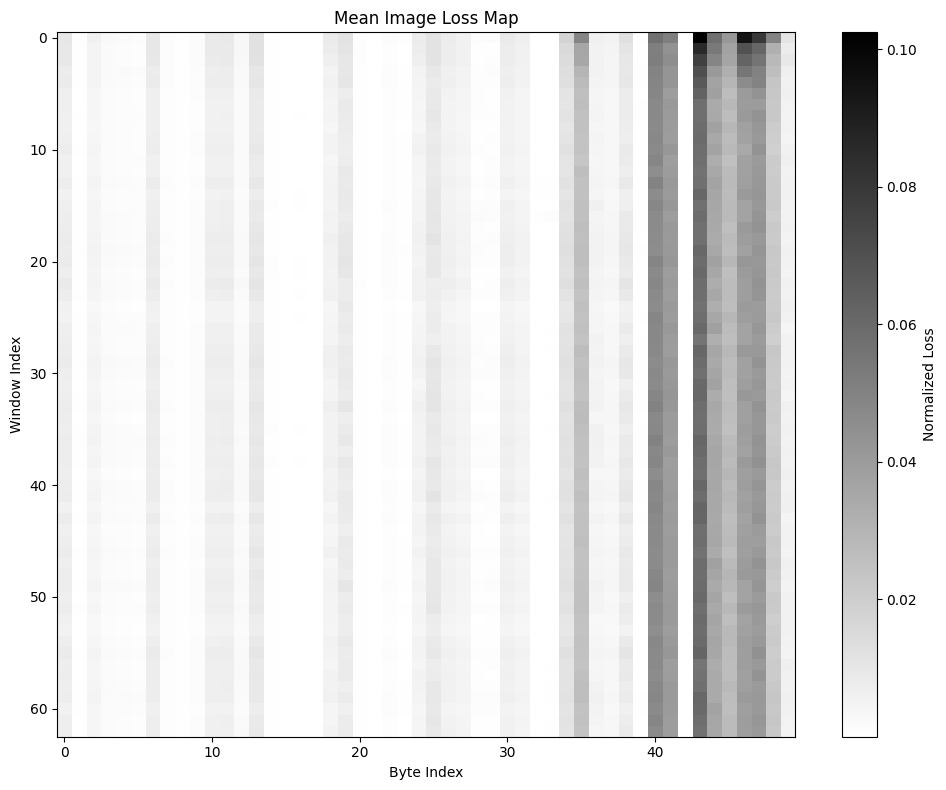

In [15]:
idx = y_true[y_true['label'] == 'Normal'].index
plot_img_loss(y_scores[idx].mean(0))

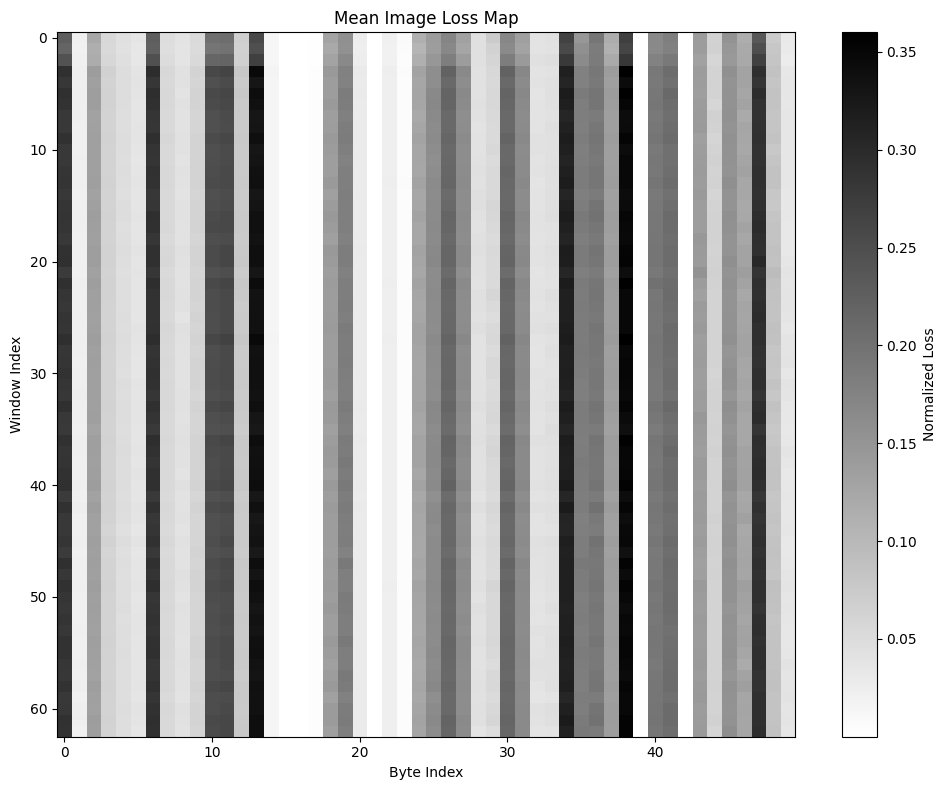

In [22]:
idx = y_true[y_true['label'] != 'Normal'].index
plot_img_loss(y_scores[idx].mean(0))

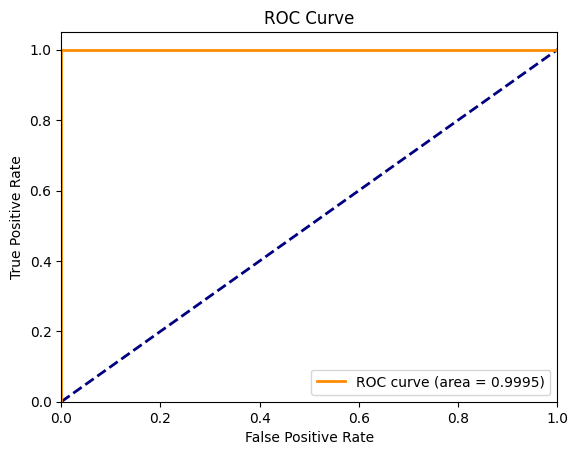

In [23]:
from sklearn.metrics import roc_auc_score, roc_curve


fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
aucroc = roc_auc_score([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
plt.figure()
plt.plot([0, 2], [0, 2], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {aucroc:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
plt.close()

In [36]:
fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
df_val_roc = pd.DataFrame({'fpr':fpr, 'tpr':tpr, 'thresholds':thresholds})
df_val_roc['youden-index'] = df_val_roc['tpr'] - df_val_roc['fpr']
df_val_roc.sort_values('youden-index', ascending=False).drop_duplicates('fpr')

,fpr,tpr,thresholds,youden-index
12,0.000284,0.999786,0.013931,0.999501
10,0.000000,0.999143,0.015683,0.999143
14,0.186754,1.000000,0.008352,0.813246
15,1.000000,1.000000,0.002746,0.000000
